<center>$\Huge{\textbf{Q1}}$</center>

I have read and understood the instructions of the cover page

In [1]:
!pip install sympy numpy matplotlib scipy

In [4]:
#Importing the libraries
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

<center>$\Huge{\textbf{Q2}}$</center>

#### **2a)** ####



The property used -

* The sum of all elements in a single row of stochastic matrix must be equal to 1

Why this property must hold mathematically -

* Sample Space: The row in a stochastic matrix account for every possible outcome because the system must transition into one of the available states (including remaining in the same state)

* Mutual Exclusivity: The transition outcomes are mutually exclusive, since the system cannot exsist in 2 different states at the same time.

* Fundamental Axiom of Probability: According to probability theory. the sum of probabilities for set of collectively exhaustive events must exactly equal to 1






In [3]:
''' USING SYMPY LIBRAY FOR SOLVING THE MATRIX SYMBOLICALLY '''
x=sp.symbols('x')   # Making x as special symbol
P_initial = sp.Matrix([
    [0.21, 0.07, 0.15, 0.11, 0.46],
    [0.0,  1.0,  0.0,  0.0,  0.0 ],
    [0.16, 0.16, 0.22, x,    0.26],
    [0.0,  0.0,  0.0,  1.0,  0.0 ],
    [0.21, 0.27, 0.18, 0.24, 0.10]
])
P_initial

Matrix([
[0.21, 0.07, 0.15, 0.11, 0.46],
[ 0.0,  1.0,  0.0,  0.0,  0.0],
[0.16, 0.16, 0.22,    x, 0.26],
[ 0.0,  0.0,  0.0,  1.0,  0.0],
[0.21, 0.27, 0.18, 0.24,  0.1]])

In [4]:
'''SOLVING THE ROW EQUATION USING SYMPY'''
row_sum = sum(P_initial[2,:])
print(f"sum of row: {row_sum}")
# Using sympy to solve the equation: row_sum = 1
solution = sp.solve(sp.Eq(row_sum, 1), x)
calculated_value=round(solution[0],1)
print("The unkown value of x is",calculated_value)

sum of row: x + 0.8
The unkown value of x is 0.2


In [5]:
'''SUBSTITUTUING THE VALUE OF X=0.2'''
final_matrix = P_initial.subs(x, calculated_value)
final_matrix

Matrix([
[0.21, 0.07, 0.15, 0.11, 0.46],
[ 0.0,  1.0,  0.0,  0.0,  0.0],
[0.16, 0.16, 0.22,  0.2, 0.26],
[ 0.0,  0.0,  0.0,  1.0,  0.0],
[0.21, 0.27, 0.18, 0.24,  0.1]])

In [6]:
'''
CONVERTING SYMPY ARRAY TO NUMPY ARRAY FOR FURTHER OPERATIONS
'''
P = np.array(final_matrix.tolist(), dtype=float)  # now substituting the value back into the matrix
P = np.round(P, 2)      #  Rounding upto to 2 decimal places
P

array([[0.21, 0.07, 0.15, 0.11, 0.46],
       [0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.16, 0.16, 0.22, 0.2 , 0.26],
       [0.  , 0.  , 0.  , 1.  , 0.  ],
       [0.21, 0.27, 0.18, 0.24, 0.1 ]])

#### **2b)** ####

In [7]:
# vector containing the inital distibution of states
vector_0 = np.array([0.13, 0.24, 0.32, 0.28, 0.03])

In [8]:
# Calculating the generations using dot product
vector_1=np.dot(vector_0,P)
vector_2=np.dot(vector_1,P)
vector_3=np.dot(vector_2,P)

In [9]:
print(f"Generation 1 {vector_1}")
print(f"Generation 2 {vector_2}")
print(f"Generation 3 {vector_3}")

Generation 1 [0.0848 0.3084 0.0953 0.3655 0.146 ]
Generation 2 [0.063716 0.369004 0.059966 0.428928 0.078386]
Generation 3 [0.03943598 0.4042229  0.0368594  0.4667426  0.05273912]


  The states A, C, and E are transient, and states B and D are absorbing. As the distribution evolves, the probability mass is transferred into absorbing states. This can be verified by the higher values of B and D states, which are 0.404 and 0.466
 respectively. Finally, the system will reach a state where the probabilities of A, C, and E are zero, and the entire distribution is contained within the absorbing boundaries of B and D.

#### **2c)** ####

In [10]:
import numpy as np
P = np.array([
    [0.21, 0.07, 0.15, 0.11, 0.46], # A  (Transient)
    [0.0,  1.0,  0.0,  0.0,  0.0 ], # B (Absorbing)
    [0.16, 0.16, 0.22, 0.20, 0.26], # C (Transient)
    [0.0,  0.0,  0.0,  1.0,  0.0 ], # D (Absorbing)
    [0.21, 0.27, 0.18, 0.24, 0.10]  # E (Transient)
])

# 2. Identifying Absorbing vs Transient indices automatically
# An absorbing state has a 1.0 on the diagonal
is_absorbing = np.isclose(np.diag(P), 1.0)
abs_idx = np.where(is_absorbing)[0]
trans_idx = np.where(~is_absorbing)[0]

# 3. Extracting Q and R using index slicing
# Q: Transitions from Transient to Transient
Q = P[np.ix_(trans_idx, trans_idx)]

# R: Transitions from Transient to Absorbing
R = P[np.ix_(trans_idx, abs_idx)]

print("Identified Transient Indices:", trans_idx)
print("Identified Absorbing Indices:", abs_idx)
print("\nAutomatically Extracted Q:\n", Q)
print("\nAutomatically Extracted R:\n", R)

Identified Transient Indices: [0 2 4]
Identified Absorbing Indices: [1 3]

Automatically Extracted Q:
 [[0.21 0.15 0.46]
 [0.16 0.22 0.26]
 [0.21 0.18 0.1 ]]

Automatically Extracted R:
 [[0.07 0.11]
 [0.16 0.2 ]
 [0.27 0.24]]


In [11]:
#Making the canonical matrix
# combining the transition and absolute index
combined_indices=np.concatenate((trans_idx,abs_idx))
P_canonical=P[np.ix_(combined_indices,combined_indices)]
P_canonical

array([[0.21, 0.15, 0.46, 0.07, 0.11],
       [0.16, 0.22, 0.26, 0.16, 0.2 ],
       [0.21, 0.18, 0.1 , 0.27, 0.24],
       [0.  , 0.  , 0.  , 1.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 1.  ]])

#### **2d)** ####


 The formula used in this question is


 $$N = (I - Q)^{-1}$$

* N (the fundamental matrix)- Nij tells us the expected number of visits to transient state j starting from transient state i before absorption.

* I (the identity matrix) - Representing the initial state at t=0

* Q (Transient sub-matrix) - Contains probabilities of staying transient.


In [12]:
# Finding the fundamental matrix N
I=np.eye(3)   # Defining an identity matrix of same sze as Q
N=np.linalg.inv(I-Q) # Using the linealg function to find the fundamental matrix N
N

array([[1.64119212, 0.54556112, 0.99643807],
       [0.49746757, 1.53899334, 0.69885928],
       [0.48243834, 0.43509626, 1.48338518]])

#### **2e)** ####


$$M = N \times \begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix}$$

Explanation of the Formula

* $M$: A vector whose elements are the number of transitions between the initial state $i$ and an absorption state (how far $i$ is from absorption).

* $N$: The Fundamental Matrix, $(I - Q)^{-1}$.


* $\begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix}$: A column vector of ones used to sum the rows of $N$.

In [13]:
# Create a column vector of ones for the 3 transient states
ones = np.ones((3, 1))

# Matrix multiplication to find M
M = np.matmul(N, ones)
M

array([[3.18319131],
       [2.7353202 ],
       [2.40091979]])

#### **2f)** ####


The formula used in this question is


$$B = NR = (I - Q)^{-1} R$$

Explanation of the Formula

* $B$ (Absorption Probability Matrix): The probability if the process started in transient state $i$ will stop at an absorbing state $j$.

* $N$ or  $(I - Q)^{-1}$ (The Fundamental Matrix): This matrix tells us the expected number of visits to transient state j starting from transient state i before absorption.

* $R$ (Transition Sub-matrix): The probability of moving from a transient state directly into an absorbing state is denoted by the transition sub-matrix.

In [14]:
#Calculating th Absorption Probability matrix B
B=np.matmul(N,R)
B

array([[0.47121151, 0.52878849],
       [0.46975367, 0.53024633],
       [0.50390009, 0.49609991]])

<center>$\Huge{\textbf{Q3}}$</center>


#### **3a)** ####

In [15]:
def student_number_converter(student_number):
  '''
    Function to convert the student ID number into 2 distinct alpha and beta values

    Parameters:
    student_number (int)- A 7-digit integer.

    Returns:
     A pair of float values:
        - first_val: The first three digits divided by 100.
        - last_val: The last three digits divided by 100.

   '''
  # Using floor division to find the first 3 numbers
  first_3_digits=student_number//10000
  # Using modulo division to find the last 3 numbers from the student number
  last_3_digits=student_number%1000
  return first_3_digits/100,last_3_digits/100


In [16]:
student_number=3456526
#Calling the converter function to find alpha and beta values
alpha,beta=student_number_converter(student_number)
print(f"The values of alpha and beta are {alpha,beta}")

The values of alpha and beta are (3.45, 5.26)


**Theoretical Expectation of the Trajectory**

The Genralized Random Walk Equation is:$$dS = \left( \frac{1}{3.45} \sin(x) \cos(t) \right)dt + \left( \frac{1}{5.26} \right)dW$$



Now to predict the behaviour of a single walk trajectory the 2 components of SDE equation need to be analysed.

* Drift Component Analysis $a(x, t) = \frac{1}{\alpha} \sin(x) \cos(t)$:

   This is the deterministic part of the equation.  

   The $\cos(t)$ part of the component ensures that the drift is not unidirectional. Due to the nature of $\cos(t)$, the drift periodically switches between an upward force and a downward force. Also, due to this upward and downward force of $\cos(t)$, the time average over a long interval is zero. Therefore, it can be said that there will be no upward or downward trend in the long term. The $\sin(x)$ part is responsible for making the drift component, dependent on the particle's current position x. The $\sin(x)$ part also creates a "restoring effect" since the drift factor varies as it moves through various spatial phases.

 * Diffusion Component Analysis $b(x, t) = \frac{1}{\beta}$      
   This is the noise component of the SDE equation. Since $1/5.26 \approx 0.19$ is a constant value, a degree of randomness will be added at each step of the random walk. This will also ensure that the trajectory has stochastic fluctuations.
<br>

**Overall Predicted Behaviour**   

  The trajectory is expected not to have a clear long-term trend and oscillate around the horizontal axis. The constant noise or diffusion component will likely try to make the system wander in a bounded range, while the drift component will ensure that the system stays in a periodic pattern




#### **3b)** ####

The scaling factor of Weiner process increment is the missing element in the code provided by the student. The scaling factor of Weiner process increment is represented by $\sqrt{dt}$.
The weiner process increment over a small time interval $dt$ is defined  mathematically as
$$dW = \epsilon \sqrt{dt}$$where $\epsilon \sim N(0, 1)$ is a standard normal random variable.


In [17]:
np.random.seed(42)
def simulate_walk_with_time(N, dt, alpha, beta, x_init=0):
      '''
      Function to simulate random walk with time

      Parameters:
      N (int)- Number of steps of random walk.
      dt (float)- Time step.
      alpha (float)- Drift coefficient.
      beta (float)- Diffusion coefficient.

      Returns:
      t_history (list): List of time points.
      x_history (list): List of location points.

      '''
      x_history =[] # For tracking the location history
      t_history = [] # For tracking the time history
      x = x_init #Initializing the location for the random walk

      for i in range(N): #running a loop for number of steps N
          t = i * dt
          # Writing the drift component of the equation
          drift = (1/alpha) * np.sin(x) * np.cos(x) * dt
          #Writing the diffusion component of the equation and adding the scaling component missing in the orignal code
          diffusion = (1/beta) * np.random.normal(0, 1) * np.sqrt(dt)
          # adding the drift and diffusion components to form Generalized random walk equation
          x = x + drift + diffusion
          #Appending the location and time history
          x_history.append(x)
          t_history.append(t)

      return t_history, x_history

#### **3c)** ####

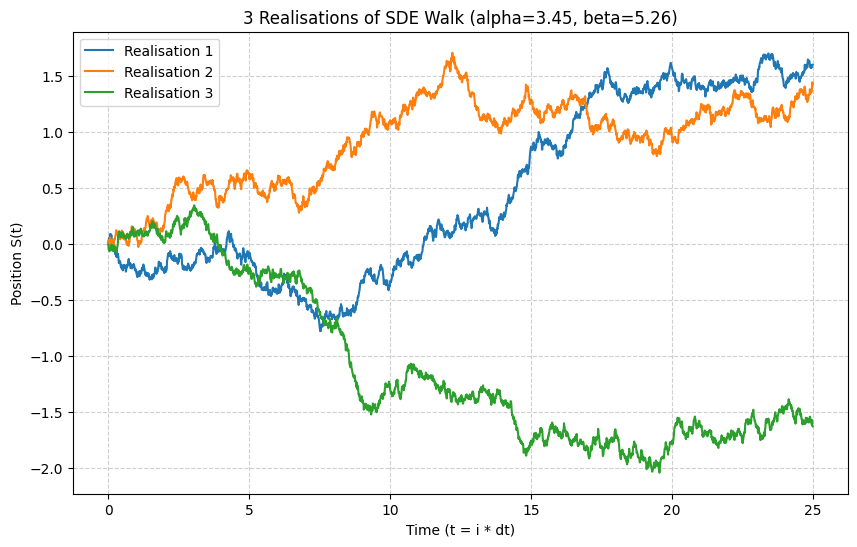

In [18]:
# Simulation and Plotting
N = 2500 #Initializing the no of walks
dt = 0.01 #Initializing the time step

plt.figure(figsize=(10, 6))
# Running the loop for 3 realizations
for i in range(3):
    # calling the random walk function and storing the time and location history
    time_axis, path = simulate_walk_with_time(N, dt, alpha, beta)
    #plotting location and time history together
    plt.plot(time_axis, path, label=f'Realisation {i+1}')

#Labelling the graph output
plt.title(f"3 Realisations of SDE Walk (alpha={alpha}, beta={beta})")
plt.xlabel("Time (t = i * dt)")
plt.ylabel("Position S(t)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


The realizations differ due to stochastic or diffusion component $\frac{1}{\beta}dW$. Also the Weiner process increment $dW = \epsilon \sqrt{dt}$ where ϵ∼N(0,1) is a standard normal random variable. In Python, numpy generates the random values for the noise component. For every new run, these random numbers have different values.
Since each of the 2,500 steps pulls a different value from a normal distribution, these small variations accumulate over time, causing the trajectories to diverge into different paths despite sharing the same underlying drift and diffusion rules.

#### **3d)** ####

For this question I calculated the mean as well as variance for each dt

In [19]:
dt_sample_space=[0.05, 0.1, 0.2, 0.4]
#Defining the no of independent walks
independent_walks=1000
#Making a dictionary to store the mean and variance of final positions
results={}
for dt in dt_sample_space:
  final_position=[]
  for i in range(independent_walks):
    _,positions=simulate_walk_with_time(N, dt, alpha, beta)
    #appending the last position after every independent walk
    final_position.append(positions[-1])
  results[dt]=[np.mean(final_position),np.var(final_position)]
print(results)

{0.05: [np.float64(0.07123470340026097), np.float64(2.563852594244947)], 0.1: [np.float64(0.012472550324794024), np.float64(2.5726223061272475)], 0.2: [np.float64(0.10621394123815622), np.float64(2.7272525545441577)], 0.4: [np.float64(-0.03341644932940341), np.float64(2.7864173193674735)]}


In [20]:
for dt in results:
  print(f"The mean and variance for dt= {dt} : Mean={results[dt][0]} and Variance={results[dt][1]}")

The mean and variance for dt= 0.05 : Mean=0.07123470340026097 and Variance=2.563852594244947
The mean and variance for dt= 0.1 : Mean=0.012472550324794024 and Variance=2.5726223061272475
The mean and variance for dt= 0.2 : Mean=0.10621394123815622 and Variance=2.7272525545441577
The mean and variance for dt= 0.4 : Mean=-0.03341644932940341 and Variance=2.7864173193674735


For $dx = a\,dt + b\,dW$  in small time  $$\delta x = a \delta t + b \epsilon \sqrt{\delta t}$$ where $\epsilon \sim \mathcal{N}(0, 1)$ <br>

Mean= $E[\delta x] = a \delta t$ <br>

Variance= $\text{Var}[\delta x] = b^2 \delta t$



The mean in the simulation is around 0 this is because the drift term  $a = \frac{1}{\alpha} \sin(x) \cos(t)$ is symmetric. This result was expected since the cos(t) part in the drift term is periodic and its average value is 0 over long time. Also sin(x) is an odd function, the forces exerted due to drift on positions +x and -x cancel each other, which also makes the final position's mean=0.





There is a slight increase in the value of the variance of final positions. Since the variance increases with increasing $\delta t$. However, the variance obtained is still very low, and the increase is very small, which is therefore the unexpected result. For example, the variance after N steps for dt=0.4 and 1000 independenrt walks should have been $$2500 \times b^2 \delta t=\text{Total Var} = \left( \frac{1}{5.26} \right)^2 \times 2500 \times 0.4 \approx 36.14$$ However, the value obtained was only 2.78 during the simulations. This is due to the fact that the drift part of the equation is creating a deterministic pull, and stopping the particles to wander randomly and create high variablilty.

#### **3e)** ####

In [21]:
def Plotting_Hist(alpha,beta):
      '''
      Function to plot the histogram of the final positions for 5000 independent walks

      Parameters:
      alpha (float)- Drift coefficient.
      beta (float)- Diffusion coefficient.

      Returns:
      final_positions (numpy.ndarray): Array of final positions for 5000 independent walks.
      '''
      dt=0.01
      independent_walks=5000
      final_position=[]
      for i in range(independent_walks):
          _,positions=simulate_walk_with_time(N, dt, alpha, beta)
          final_position.append(positions[-1])
      final_positions = np.array(final_position)
      # Plotting the Histogram
      plt.figure(figsize=(10, 6))
      plt.hist(final_positions, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)

      # Overlaying a Normal Distribution curve for comparison with the original curve
      mu, std = np.mean(final_positions), np.std(final_positions)
      xmin, xmax = plt.xlim()
      x_axis = np.linspace(xmin, xmax, 100)
      p = stats.norm.pdf(x_axis, mu, std)
      plt.plot(x_axis, p, 'r', linewidth=2, label='Normal Distribution Curve')

      plt.title(f"Histogram of Final Positions (5000 walks, dt=0.01,alpha={alpha},beta={beta})")
      plt.xlabel("Final Position S(T)")
      plt.ylabel("Probability Density")
      plt.legend()
      plt.grid(axis='y', alpha=0.3)
      plt.show()
      return final_positions


In [22]:
def normality_test(final_positions):
  '''
  Function to perform Shapiro-Wilk test for normality on the final positions
  Params- final_positions (numpy.ndarray)
  Returns- None
  '''
  shapiro_test = stats.shapiro(final_positions)
  print(f"Shapiro-Wilk Test: Statistics={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4e}")

  if shapiro_test.pvalue > 0.05:
      print("Conclusion: The distribution is likely Normal (fail to reject H0).")
  else:
      print("Conclusion: The distribution is NOT Normal (reject H0).")

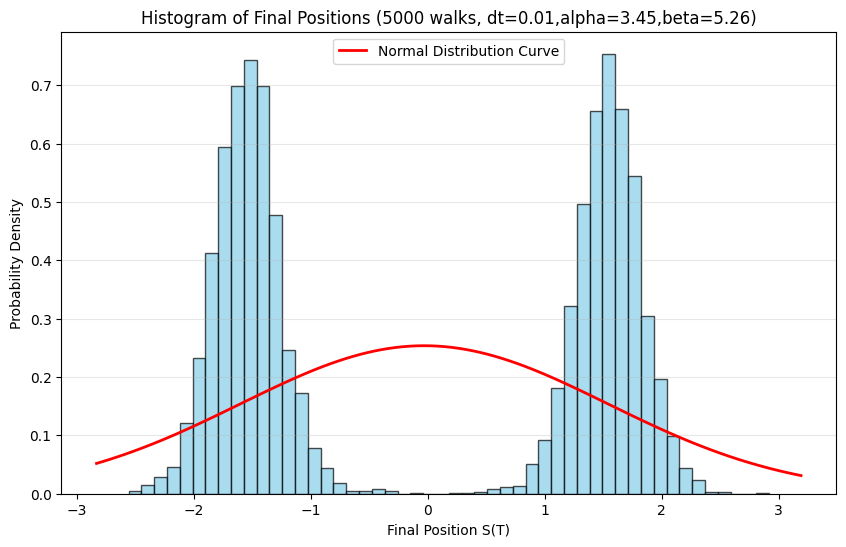

In [23]:
final_positions=Plotting_Hist(alpha,beta)

From the visual presentation the distribution appears to be bimodal normal distribution with 2 peaks


Now performing shapiro-wilk test to check if the distribution is normally distributed or not. Defining the null and alternate hypothesis for testing the normality.

Null Hypothesis ($H_0$): The sample data is drawn from a normally distributed population.

Alternative Hypothesis ($H_1$): The sample data is not drawn from a normally distributed population.

In [24]:
normality_test(final_positions)

Shapiro-Wilk Test: Statistics=0.7886, p-value=1.2090e-62
Conclusion: The distribution is NOT Normal (reject H0).


* The low p value indicates that the we can reject the null hypothesis and say that distribution is most likely not normally distributed.

* From the visual presentation the distribution appears to be bimodal normal
distribution with 2 sharp peaks with very few values in the middle.

Now testing if changing the values of alpha and beta have a effect on the distribution of the final positions. For the first test I will increase the value of alpha significantly in comparision to beta (alpha>>beta).

Alpha=10 and beta=1

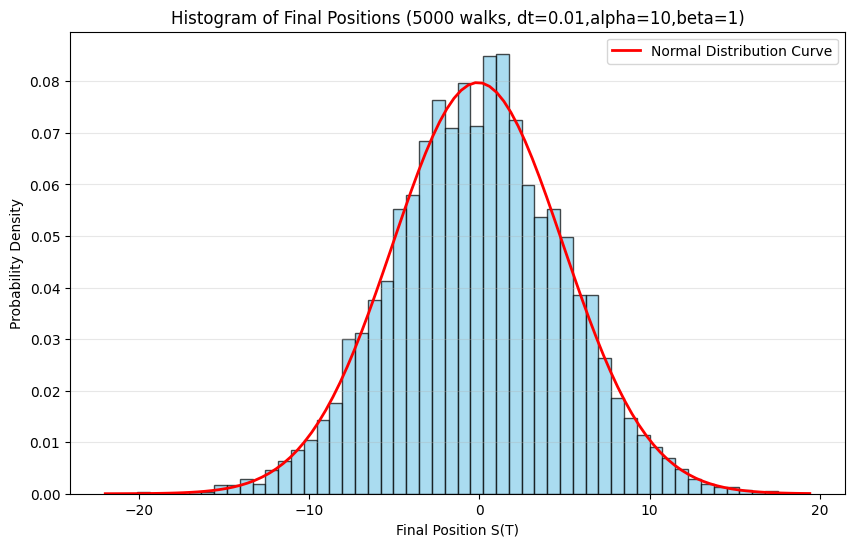

In [25]:
final_positions_alpha_greater=Plotting_Hist(10,1)

In [26]:
normality_test(final_positions_alpha_greater)

Shapiro-Wilk Test: Statistics=0.9998, p-value=9.7204e-01
Conclusion: The distribution is likely Normal (fail to reject H0).


The normality test shows that the distribution becomes normal (due to p_value>0.05) when alpha is greater than beta and can be verified visually also.

Now testing what happens when beta is signifcantly greater than alpha  (alpha<< beta).

alpha=1 and beta=10

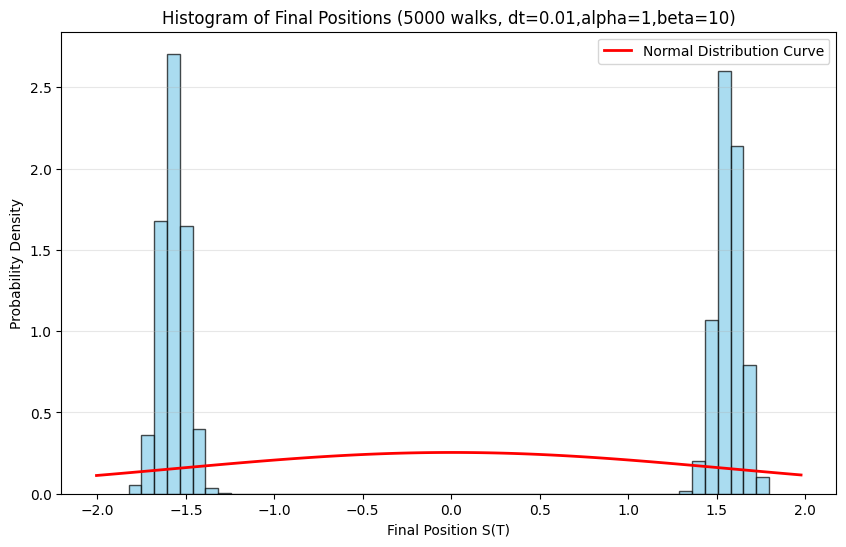

In [27]:
final_positions_beta_greater=Plotting_Hist(1,10)

In [28]:
normality_test(final_positions_beta_greater)

Shapiro-Wilk Test: Statistics=0.6782, p-value=6.5566e-71
Conclusion: The distribution is NOT Normal (reject H0).


The normality test shows that the distribution is not normal (due to p_value<0.05) when alpha is smaller than beta and this can be verified visually also. We can see 2 very sharp distinct peaks.
Since in my roll number, also the value of alpha (3.45) is slighty smaller than beta (5.26) therefore 2 distinct peaks are visible. However the difference between alpha and beta is not too great therefore those 2 peaks are not very sharp.

#### **3f)** ####

In [29]:
#Creating a boolean mask (True if within 2, False if not)
mask = np.abs(final_positions) <= 2
# Counting how many of those are True
success_count = np.sum(mask)
# Dividing by total no of walks
prob = success_count / len(final_positions)
print(f"Successes: {success_count}")
print(f"Total Walks: {len(final_positions)}")
print(f"Probability: {prob}")

Successes: 4748
Total Walks: 5000
Probability: 0.9496


The calculated probability $P(|x| \leq 2) \approx 0.95$ is dependent on both N and dt. To achieve a steady-state bimodal distribution in a system, a sufficiently large value of N is required. Also, the value of dt should be small so that the noise does not overshoot the random walker very far and decrease the value of $P(|x| \leq 2)$. Therefore, a small dt and large enough N are required to keep the probability $P(|x| \leq 2) \approx 0.95$.

<center>$\Huge{\textbf{Q4}}$</center>

#### **4a)** ####


 i.Having an algorithm like a greedy hill climber that only accepts improvements
 mostly gets stuck at the top of the very first hill it finds, even if the hill is not the global maxima. Metropolis Hastings allows the solver to jump across valleys to find other parts of 4d space. This significantly increases the chance of finding the global maximum


 ii. Small ($\sigma = 0.01$) vs. Large ($\sigma = 10$)- If the standard deviation is small, the algorithm will take too long to explore the dimension. A small standard deviation results in very small steps, and the algorithm stays stuck in the local peak. However, if the standard deviation is too large, it results in a jump that very often lands outside the specified domain of the objective function. This also leads to a high rejection rate, and the algorithm barely moves forward. The preference of standard deviations mostly depends on sturcture of the problem. Small $\sigma$ is preffered in problems having smooth, single peak landscapes or near optima. Large $\sigma$ in problems having widely separated peaks or unbounded domains.  


 iii. Grid Search disadvantage  - Grid Search is computationally very expensive because it evaluates every point in a dimension, and therefore suffers from the curse of dimensionality. It will hence take a long time to evaluate a 4d space. Metropolis-Hastings algorithm, on the other hand, finds interesting high-value regions in higher dimensions and does not waste time evaluating every single empty corner of the 4D domain.

#### **4b)** ####

The Metropolis Acceptance Criterion is missing in the student's code. The student's algorithm uses a simple f_proposal > f_current if condition. This will make the algorithm stuck in local maxima, and is actually an implementation of a simple greedy search algorithm. The core of the Metropolis algorithm, which is the probabilistic ratio $alpha = min(1, exp(f_{proposal} - f_{current}))$, is missing in the algorithm. This ratio helps the algorithm to not get stuck in a local optimum.

In [7]:
def metropolis_hastings_optimizer(func, x_init, sigma, n_steps):
    """
    Metropolis-Hastings algorithm for optimization.

     Parameters:
      func (callable): The objective function to be minimized.
      x_init (numpy.ndarray): Initial position.
      sigma (float): Standard deviation for the Gaussian proposal distribution.
      n_steps (int): Number of steps.

      Returns:
      history (list): List of function values at each step.
      x_current (numpy.ndarray): Current position.
    """
    x_current = np.array(x_init)
    f_current = func(*x_current)
    history = [f_current]
    accepted_moves=0
    for i in range(n_steps):
        #Calculating the proposals
        x_proposal = x_current + np.random.normal(0, sigma, size=4)
        f_proposal = func(*x_proposal)
         # Compute ratio
        ratio = np.exp(f_proposal - f_current)
        alpha = min(1, ratio)
        #  Accept/Reject
        u = np.random.uniform(0, 1)
        if u <= alpha:
            x_current = x_proposal
            f_current = f_proposal
            accepted_moves+=1
        history.append(f_current)
    acceptance_ratio=accepted_moves/n_steps
    return history,x_current,acceptance_ratio

In [2]:
def f(w, x, y, z):
    """
    The 4D objective function

    Parameters:
    w, x, y, z (float): Coordinates.

    Returns:
    float: Value of the objective function.
    """
    # Boundary Check: Domain is -3.5 <= w, x, y, z <= 3.5
    if any(abs(val) > 3.5 for val in [w, x, y, z]):
        return -np.inf # Return negative infinity for out-of-bounds

    # Himmelblau-like components
    himmel1 = -((w**2 + x - 11)**2 + (w + x**2 - 7)**2) / 100
    himmel2 = -((y**2 + z - 11)**2 + (y + z**2 - 7)**2) / 100

    # Gaussian Peaks
    peak1 = 4.0 * np.exp(-0.2 * ((w - 2.5)**2 + (x - 1.8)**2 + (y + 1.2)**2 + (z - 0.7)**2))
    peak2 = 3.8 * np.exp(-0.18 * ((w + 1.8)**2 + (x - 2.2)**2 + (y - 2.5)**2 + (z + 1.5)**2))
    peak3 = 3.5 * np.exp(-0.22 * ((w - 0.5)**2 + (x + 2.8)**2 + (y - 1.8)**2 + (z + 2.3)**2))
    peak4 = 3.3 * np.exp(-0.25 * ((w + 2.2)**2 + (x + 0.8)**2 + (y + 2.5)**2 + (z - 2.1)**2))

    # Interaction term
    interaction = 0.2 * np.sin(w + x) * np.cos(y - z)

    return himmel1 + himmel2 + peak1 + peak2 + peak3 + peak4 + interaction

#### **4c)** ####

**i)**

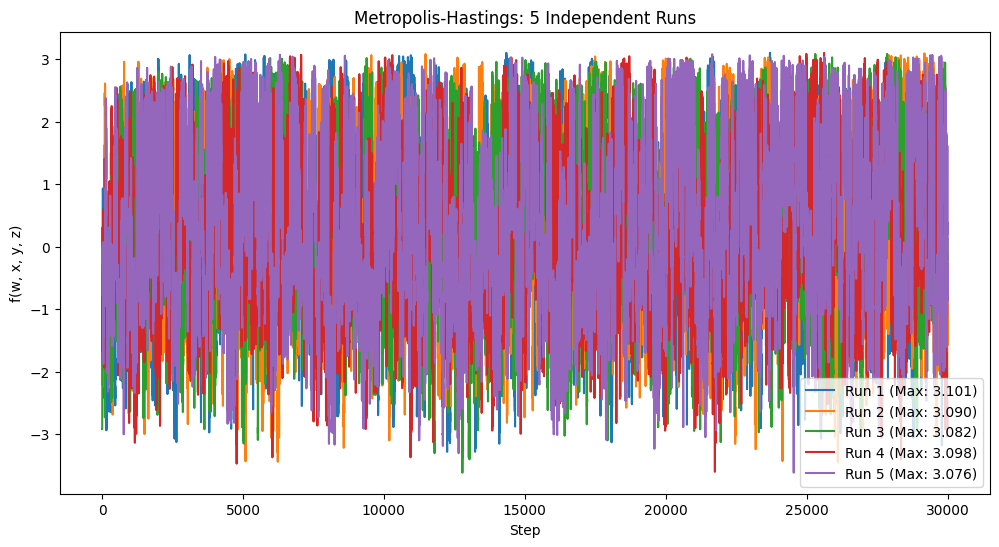

In [5]:
#PLOTTING ALL 5 CURVES FUNCTION VS STEP
plt.figure(figsize=(12, 6))
#Storing all the results in a list
all_results = []
#Running a loop for 5 runs
for seed in range(5):
    #Initializing the coordinates with different seed in each run
    np.random.seed(seed)
    #Selecting random starting position(4 D coordinate)
    start_pos = np.random.uniform(-3.5, 3.5, 4)
    #passing the objective function start position with standard deviation of 0.5 and 30000 steps
    hist, final_pos, acc_rate = metropolis_hastings_optimizer(f, start_pos, 0.5, 30000)
    #Finding the global max value
    global_max = max(hist)
    all_results.append({
        "run": seed + 1, #keeping track of the run value
        "max": global_max,# keeping track of the global maximum value
        "final_pos": final_pos, #storing the final positon of global maximun
        "acc_rate": acc_rate  # storing the acceptance ratio
    })

    plt.plot(hist, label=f"Run {seed+1} (Max: {global_max:.3f})")
#plotting
plt.legend()
plt.title("Metropolis-Hastings: 5 Independent Runs")
plt.xlabel("Step")
plt.ylabel("f(w, x, y, z)")
plt.show()

In [6]:
#Printing the results of each run
for values in all_results:
  print(f"run={values['run']}: maximum_value={values['max']}, coordinates (w,x,y,z)={values['final_pos']}, acceptance rate={values['acc_rate']}")
  print("")

run=1: maximum_value=3.1007594361098274, coordinates (w,x,y,z)=[2.3464176  2.95108426 2.22861024 2.57868122], acceptance rate=0.6177666666666667

run=2: maximum_value=3.0900313742739565, coordinates (w,x,y,z)=[ 2.64851887  0.38153658 -1.15164674 -1.61332519], acceptance rate=0.6174

run=3: maximum_value=3.0819467202575983, coordinates (w,x,y,z)=[2.67360598 2.57623201 2.2541135  0.80297668], acceptance rate=0.6176666666666667

run=4: maximum_value=3.0975730308982294, coordinates (w,x,y,z)=[-2.11280504 -0.36374862 -1.35728043 -3.4578942 ], acceptance rate=0.6216

run=5: maximum_value=3.0755681686244354, coordinates (w,x,y,z)=[-0.63743455  1.24457871  2.63305585  0.43635476], acceptance rate=0.6075666666666667



**ii)** No, all the runs don't converge to the same maximum. All the maximum values found by the algorithm are very close to 3.10. Also for every run the final position $(w, x, y, z)$  are completely different.


Algorithm- The algorithm finds different values but similar maximum values. It tells that Metropolis-Hastings algorithm is able to explore the 4D space well, however the space appears to have many local optima. It also suggests that algorithm is able to successfully move around the domain, and it does not get stuck in a single spot.

The analysis also proves the objective funtion $f(w, x, y, z)$ is likely a multimodal objective function with multiple peaks of similar heights.










**iii)** For acceptance ratios for the five different runs are-

* Run 1: 61.78%
* Run 2: 61.74%
* Run 3: 61.77%
* Run 4: 62.16%
* Run 5: 60.76%

The acceptance ratios for all the five runs are very similar, since they fall between the ranges of 60.76% and 62.16%. This also indicates that the proposal distribution
$\sigma = 0.5$ interacts with the objective function in a predictable and stable way. A 60% acceptance ratio suggests that algorithm is not too lenient (100% acceptance rate) or too aggressive (< 1% acceptance rate).




**iv)** The maximum value of $f(w, x, y, z)$ based on the 5 runs is 3.10 in run 1.
So the function most likely have multiple peaks of similar height. This is because the algorithm found very similar maximum values at very different coordinates. The maximum value of 3.10 was found at the coordinates of w=2.3464176, x=2.95108426, y= 2.22861024 and z=2.57868122

#### **4d)** ####

To verify if I have found the true global maximum I will increase the no of simulations to 50. Every simulation will have a different seed value

In [34]:
all_max_values = []
best_overall_f = -np.inf
best_overall_pos = None

# Runing 50 independent simulations to verify the global maximum
for i in range(50):
    # Random starting position for each run
    np.random.seed(i)
    x_start = np.random.uniform(-3.5, 3.5, size=4)

    history, final_pos, acc_rate = metropolis_hastings_optimizer(f, x_start, 0.5, 30000)

    current_max = max(history)
    all_max_values.append(current_max)
    #Checking if the current max value is greater the best overall max value
    if current_max > best_overall_f:
        best_overall_f = current_max
        best_overall_pos = final_pos

print(f"Global Verification Complete.")
print(f"Highest value found across all runs: {best_overall_f}")
print(f"Coordinates of global max: {best_overall_pos}")

Global Verification Complete.
Highest value found across all runs: 3.1056522827061643
Coordinates of global max: [-1.73756629  1.78209142  3.39008278 -1.47028294]


By running the algorithm 50 different times, the global max came out to be 3.1056522827061643, which is almost similar to the maximum peak value of 3.1007594361098274, which was obtained after 5 independent runs. This also proves that functional is multimodal, having several peaks of nearly equal heights. Since the value of maxima is obtained after 50 runs, there is high statistical confidence that 3.10 is the global maximum of $f(w, x, y, z)$.